# NB 22 - API model showcase  (`api/fast.py`)

This notebook loads **exactly the artefacts the FastAPI service uses**
(`load_model("pca")`, `load_scaler()`, `load_target_channels()`,
`PCA_THRESHOLD`) and runs `predict()` / `predict_report()` end-to-end on
the **`test_internal` slice**.

It then visualises the result the way you'd want for a stakeholder
walk-through - metrics, timeline, event analysis, per-channel diagnostics,
and a few extras that fall out of `predict_report` (top-N channels,
score distribution, confusion matrix).

> All numbers below match what `/predict` and `/report` would return on
> this slice if it were posted to the API.

## 1 - Setup

In [17]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Same imports as api/fast.py
from sentinel.ml_logic.data      import load_target_channels, find_anomaly_segments
from sentinel.ml_logic.predictor import predict, predict_report
from sentinel.ml_logic.registry  import load_model, load_scaler
from sentinel.params             import PROCESSED_DIR, ANOMALY_COLOR, NOMINAL_COLOR, PCA_THRESHOLD

# PCA_THRESHOLD = 0.053293

# Metrics + viz helpers
from sentinel.ml_logic.metrics import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.viz     import (
    plot_timeline, plot_event_analysis,
    plot_score_distribution, plot_confusion_and_channel_errors,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('PCA_THRESHOLD :', PCA_THRESHOLD)
print('PROCESSED_DIR :', PROCESSED_DIR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PCA_THRESHOLD : 0.060404
PROCESSED_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed


## 2 - Load the API artefacts

Same four objects the FastAPI lifespan loads at startup.


In [18]:
model    = load_model('pca')
scaler   = load_scaler()
features = load_target_channels()

# # test_api slice (small demo slice)
X_int    = np.load(PROCESSED_DIR / 'test_api_2.npy')
y_int    = np.load(PROCESSED_DIR / 'y_test_api_2.npy')

# test_internal - whole internal test set from train/val/test_internal split (with labels)
#X_int    = np.load(PROCESSED_DIR / 'test_intern_raw.npy')
#y_int    = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'model     : {type(model).__name__}  (n_components={getattr(model, "n_components_", "?")})')
print(f'scaler    : {type(scaler).__name__}')
print(f'features  : {len(features)} channels  →  {features[:3]} ... {features[-3:]}')
print(f'X_int     : {X_int.shape}   {X_int.dtype}')
print(f'y_int     : {y_int.shape}   anomaly rows: {int(y_int.sum()):,} ({y_int.mean():.2%})')
print(f'threshold : {PCA_THRESHOLD}')


✅ Model loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/pca.pkl
✅ Scaler loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/scaler.pkl
model     : PCA  (n_components=38)
scaler    : RobustScaler
features  : 58 channels  →  ['channel_12', 'channel_13', 'channel_14'] ... ['channel_74', 'channel_75', 'channel_76']
X_int     : (150000, 58)   float32
y_int     : (150000,)   anomaly rows: 26 (0.02%)
threshold : 0.060404


## 3 - Run the API pipeline

`predict()` returns the `(id, is_anomaly)` table the `/predict` endpoint
serves; `predict_report()` (used by `/report`) additionally returns
`row_scores`, `per_channel_mse`, `window_channel_mse`, and `window_top_channels`.
We call both so the showcase plots have everything in hand.


In [19]:
t0 = time.time()
sub = predict(
    model=model, scaler=scaler, features=features,
    X_raw=X_int, threshold=PCA_THRESHOLD,
)
t_pred = time.time() - t0

# predict_report:
#   topk=None           -> PCA scoring (mean over all channels). Same rule
#                          as predict() so labels agree.
#   n_top_channels=6    -> diagnostic only; fills the output 'window_top_channels'

t0 = time.time()
rep = predict_report(
    model=model, scaler=scaler, features=features,
    X_raw=X_int, threshold=PCA_THRESHOLD,
    topk=None, n_top_channels=6,
)
t_rep = time.time() - t0

# Local names mirror the dict keys so it stays obvious where each piece comes from.
row_scores          = rep['row_scores']           # per-row reconstruction MSE
labels              = rep['labels']               # 0/1 predictions per row
per_channel_mse     = rep['per_channel_mse']      # mean MSE per channel across all windows
window_channel_mse  = rep['window_channel_mse']   # per-window per-channel MSE
window_top_channels = rep['window_top_channels']  # top-N channel indices per window

# Parity sanity-check: the /predict endpoint and our scores must agree.
assert np.array_equal(sub['is_anomaly'].values.astype(np.int8), labels), \
    'predict() and predict_report(topk=None) disagree - pipeline drift!'

print(f'predict()        : {t_pred:.2f}s   ->  {len(sub):,} rows')
print(f'predict_report() : {t_rep:.2f}s   ->  row_scores {row_scores.shape}, per_channel_mse {per_channel_mse.shape}')
print(f'predicted anom   : {int(labels.sum()):,} rows  ({labels.mean():.2%})')
print(f'score range      : [{row_scores.min():.4f}, {row_scores.max():.4f}]   mean {row_scores.mean():.4f}')
print(f'top-6 indices    : {window_top_channels.shape}')


predict()        : 0.11s   ->  150,000 rows
predict_report() : 0.11s   ->  row_scores (150000,), per_channel_mse (58,)
predicted anom   : 200 rows  (0.13%)
score range      : [0.0258, 3.0895]   mean 0.0348
top-6 indices    : (1500, 6)


In [20]:
# rep['window_top_channels']
window_top_channels

array([[57, 56, 54, 51, 53, 52],
       [57, 56, 55, 54, 53, 51],
       [57, 53, 56, 51, 55, 54],
       ...,
       [57, 56, 55, 54, 53, 51],
       [57, 56, 54, 51, 55, 53],
       [57, 56, 51, 53, 55, 52]])

In [21]:
# MSE for every channel averaged across all windows/rows
per_channel_mse

array([1.27862918e-03, 1.24230119e-03, 3.15802894e-03, 7.22084020e-04,
       2.86658760e-04, 2.50137458e-03, 5.81145613e-03, 7.24949781e-03,
       2.56797881e-03, 4.93232906e-03, 1.01520470e-03, 9.41440347e-04,
       3.07769282e-04, 1.54607126e-03, 3.23835504e-03, 3.02563980e-03,
       1.32447551e-03, 1.56345556e-03, 1.13681154e-02, 1.01499388e-03,
       4.77479654e-04, 5.46255033e-04, 9.01125255e-04, 2.49960925e-03,
       3.11579858e-03, 2.01428542e-03, 1.18180504e-02, 1.33930694e-03,
       4.65181394e-04, 2.93173138e-02, 6.76471516e-02, 1.73504010e-01,
       6.72555044e-02, 3.06295883e-02, 7.18811303e-02, 5.39194234e-03,
       5.49640972e-03, 4.87944996e-03, 5.19833202e-03, 5.57971327e-03,
       4.86210780e-03, 1.85376091e-03, 1.37295201e-03, 2.86630448e-03,
       1.42686383e-03, 3.12492950e-03, 1.21561425e-04, 9.41739490e-05,
       3.60459024e-10, 6.74216127e-10, 1.04348734e-02, 1.45501122e-01,
       1.21906281e-01, 1.50330082e-01, 1.35484308e-01, 1.35787264e-01,
      

In [22]:
head = sub.head(10).copy()
head['score']    = row_scores[:10].round(5)
head['gt_label'] = y_int[:10]
print(head.to_string(index=False))


 id  is_anomaly   score  gt_label
  0           0 0.02984         0
  1           0 0.02984         0
  2           0 0.02984         0
  3           0 0.02984         0
  4           0 0.02984         0
  5           0 0.02984         0
  6           0 0.02984         0
  7           0 0.02984         0
  8           0 0.02984         0
  9           0 0.02984         0


In [23]:
window_top_channels

array([[57, 56, 54, 51, 53, 52],
       [57, 56, 55, 54, 53, 51],
       [57, 53, 56, 51, 55, 54],
       ...,
       [57, 56, 55, 54, 53, 51],
       [57, 56, 54, 51, 55, 53],
       [57, 56, 51, 53, 55, 52]])

## 4 - Metrics

Threshold is fixed at `PCA_THRESHOLD` (the value the API uses); we don't
re-tune here. We compute the standard suite (event-wise, ESA-corrected,
row-level) and lay them out in a table plus a grouped bar chart so the
trade-offs are visible at a glance.


In [24]:
ef  = event_f05(y_int, labels)
esa = corrected_event_f05(y_int, labels)
rw  = row_precision_recall(y_int, labels)
n_ev_total = int(ef['tp_events'] + ef['fn_events'])
n_ev_hit   = int(ef['tp_events'])

m = {
    'event F0.5'      : ef['f_score'],
    'event precision' : ef['precision'],
    'event recall'    : ef['recall'],
    'ESA F0.5'        : esa['f_score'],
    'ESA Pr_ew'       : esa['precision'],
    'ESA TNR'         : esa['tnr'],
    'row F1'          : rw['f1'],
    'row precision'   : rw['precision'],
    'row recall'      : rw['recall'],
    'flag rate'       : float(labels.mean()),
    'events hit'      : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit/max(n_ev_total,1):.1%})',
    'fp pred events'  : int(ef['fp_pred_events']),
}
order = ['ESA F0.5','ESA Pr_ew','ESA TNR',
         'event F0.5','event precision','event recall',
         'row F1','row precision','row recall',
         'flag rate','events hit','fp pred events']
df_m = pd.DataFrame({'Metric': order, 'Value': [m[k] for k in order]})
def _fmt(v):
    if isinstance(v,(int,np.integer)): return str(int(v))
    if isinstance(v,float): return f'{v:.4f}'
    return str(v)
df_m['Value'] = df_m['Value'].map(_fmt)

print(f'API model on test_internal  ·  threshold = {PCA_THRESHOLD:.6f}')
print(df_m.to_string(index=False))

API model on test_internal  ·  threshold = 0.060404
         Metric        Value
       ESA F0.5       0.9991
      ESA Pr_ew       0.9988
        ESA TNR       0.9988
     event F0.5       1.0000
event precision       1.0000
   event recall       1.0000
         row F1       0.2301
  row precision       0.1300
     row recall       1.0000
      flag rate       0.0013
     events hit 2/2 (100.0%)
 fp pred events            0


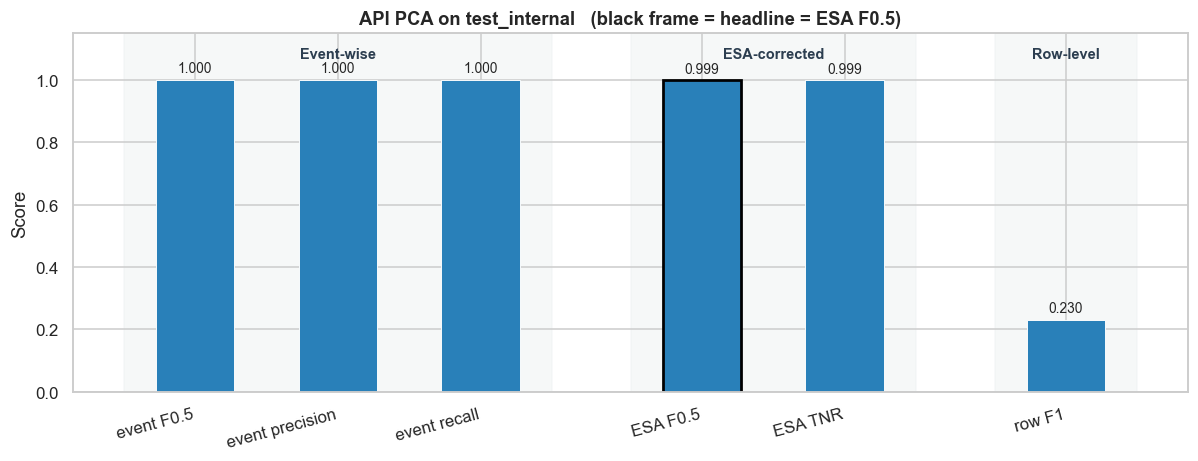

In [25]:
# Grouped bar chart - same style as nb21
BAR_GROUPS = [
    ('Event-wise',    ['event F0.5', 'event precision', 'event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['row F1']),
]
TUNE_LABEL = 'ESA F0.5'   # what we'd tune on if we did tune

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.55, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, group_labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in group_labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs = np.asarray(xs)
vals = [m[l] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]
b = ax.bar(xs, vals, w, color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b, fmt='%.3f', fontsize=9, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo+xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'API PCA on test_internal   (black frame = headline = {TUNE_LABEL})', fontweight='bold')
fig.tight_layout(); plt.show()


## 5 - Timeline

Top: per-row reconstruction MSE with the API threshold (red dashed) and
true-anomaly bands shaded behind it. Bottom: predicted-event ribbon
split into TPs (green) vs FPs (lavender). `log_y` spreads small events
that would otherwise be flattened by the largest spike.


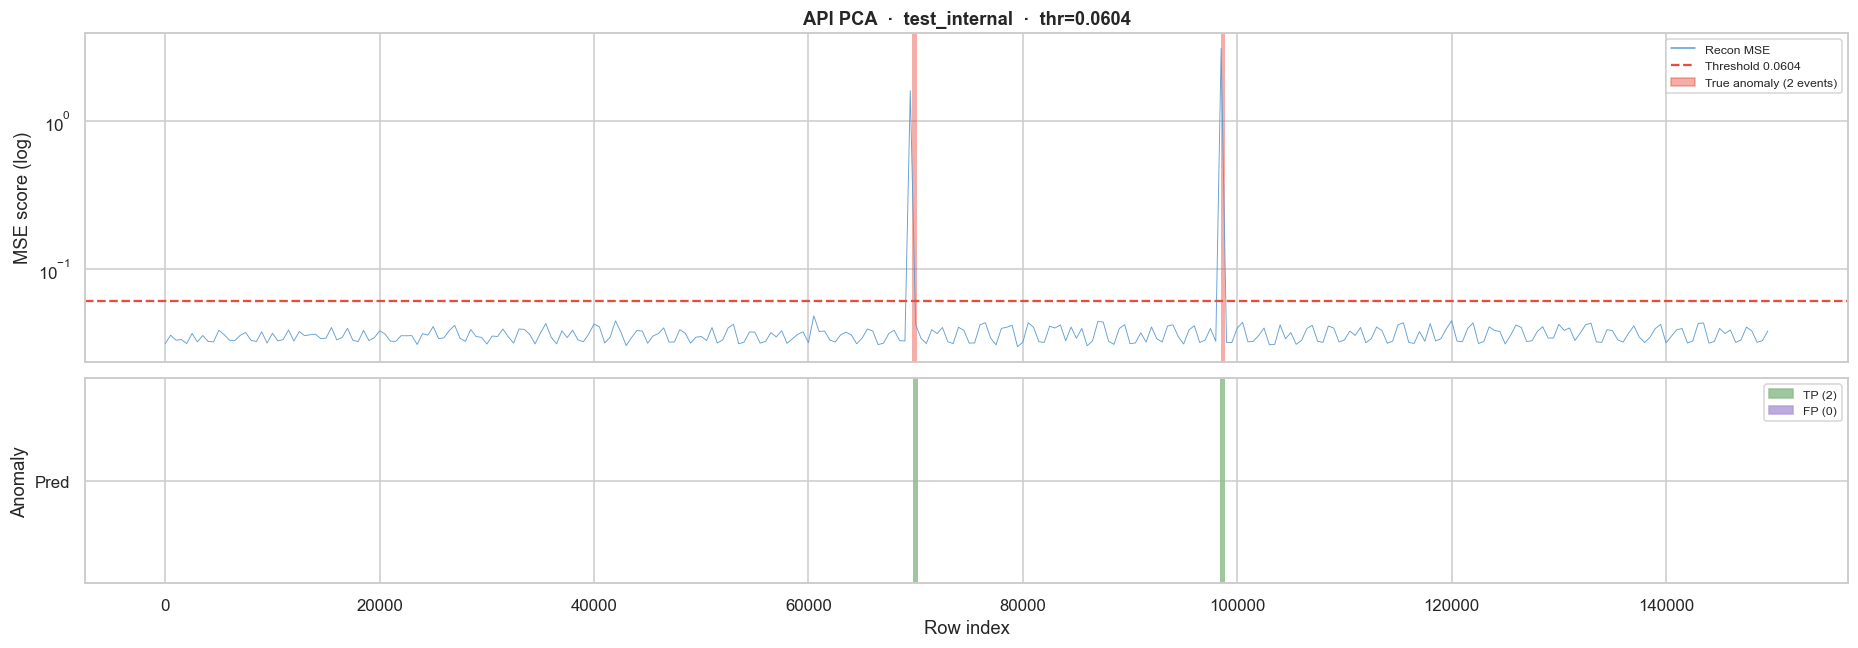

In [26]:
fig = plot_timeline(
    scores=row_scores, y_true=y_int, threshold=PCA_THRESHOLD,
    title=f'API PCA  ·  test_internal  ·  thr={PCA_THRESHOLD:.4f}',
    log_y=True,
    ## index=True,  # show row indices on x-axis
)
plt.show()


## 6 - Event analysis

Three-panel diagnostic per event:
1. Detected vs missed counts.
2. Coverage (fraction of event rows flagged) vs event length.
3. Hit-rate distribution.

Followed by the table of missed events (start / end / length) so it's
clear which segments the API model can't catch.


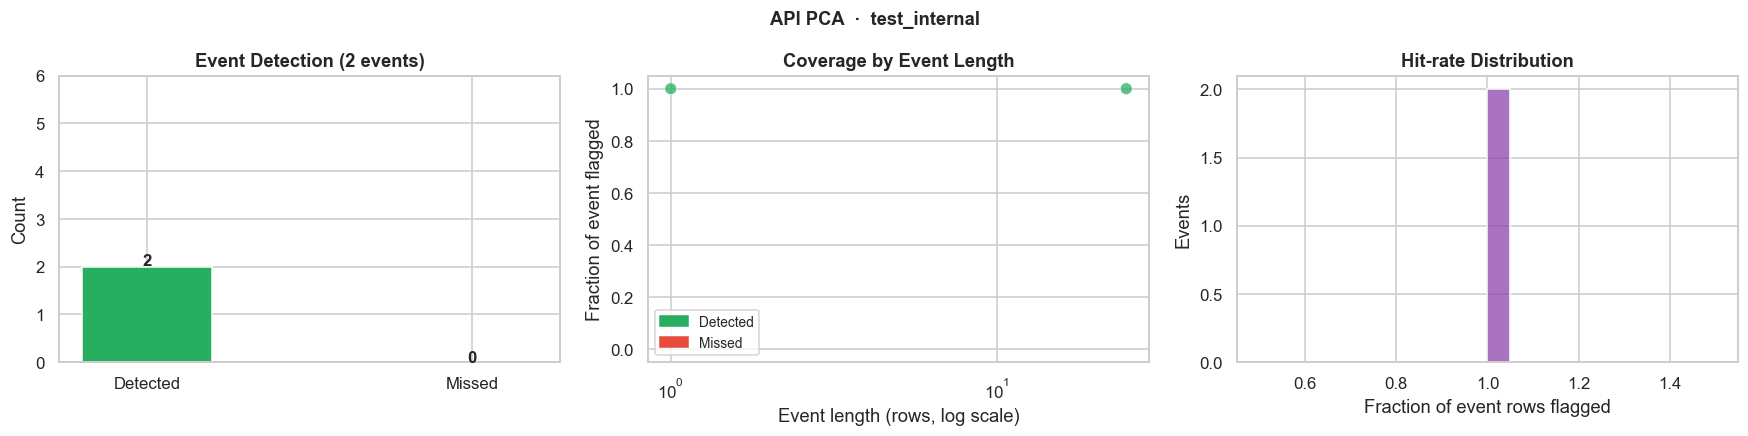

In [27]:
_ = plot_event_analysis(y_int, labels, title='API PCA  ·  test_internal')
plt.show()


## 7 - Score distribution & row-level diagnostics

* **Score histogram by class (window-level)** - one score per non-overlapping
  100-row window, labelled anomalous if it contains any anomaly row. Plotting
  at window level (not row level) is correct because PCA scores the window;
  row scores are just the window MSE broadcast, so a row-level histogram
  blends contaminated windows into both classes and exaggerates overlap.
* **Confusion matrix + per-channel MSE** - row-level confusion plus the
  top channels by mean reconstruction error. Channels driving the score
  surface here.


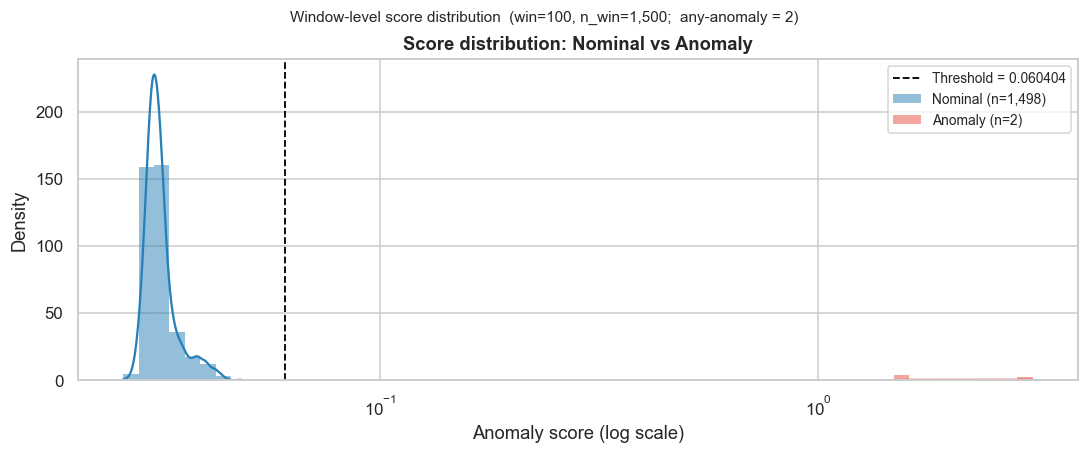

In [28]:
# Score distribution at WINDOW level (the unit the model actually decides on).
# row_scores are window-mean MSE broadcast to all 100 rows in the window - plotting
# them by row-label mixes contaminated windows into both classes. We collapse to
# one score per window and label a window anomalous if any of its rows are.
from sentinel.params import WINDOW_SIZE as WIN

n_win      = len(row_scores) // WIN
win_scores = row_scores[:n_win * WIN].reshape(n_win, WIN)[:, 0]          # constant within window
win_label  = y_int[:n_win * WIN].reshape(n_win, WIN).any(axis=1).astype("int8")

fig = plot_score_distribution(win_scores, win_label, threshold=PCA_THRESHOLD)
fig.suptitle(
    f"Window-level score distribution  (win={WIN}, "
    f"n_win={n_win:,};  any-anomaly = {int(win_label.sum()):,})",
    y=1.02, fontsize=10,
)
plt.show()


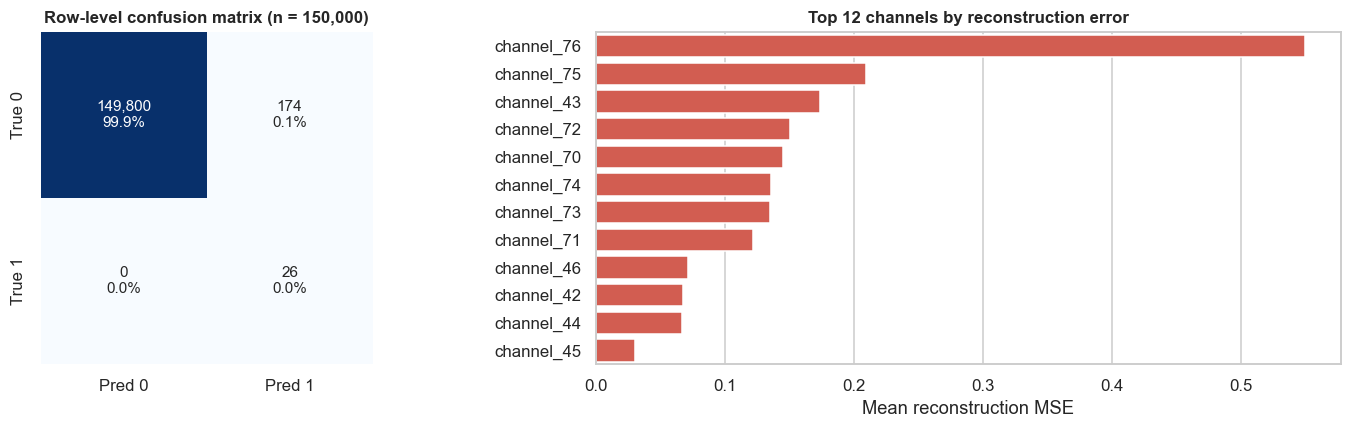

In [29]:
fig = plot_confusion_and_channel_errors(
    y_true=y_int, y_pred=labels,
    per_channel_mse=per_channel_mse,
    channel_names=features,
    top_k=12,
)
plt.show()


## 8 - Top-N channel frequency

`predict_report(n_top_channels=6)` returns, for every window, the indices
of the 6 channels with the largest reconstruction error (ranked
descending by per-channel MSE). Counting how often each channel shows up
in that top-6 tells us which channels are the *primary suspects* across
the slice - useful for explaining a flagged window to an operator (which
channel triggered it).

`n_top_channels` controls only this diagnostic; the score reduction
still uses the PCA default (mean over all channels). The `topk`
parameter is reserved for LSTM-style score reduction.


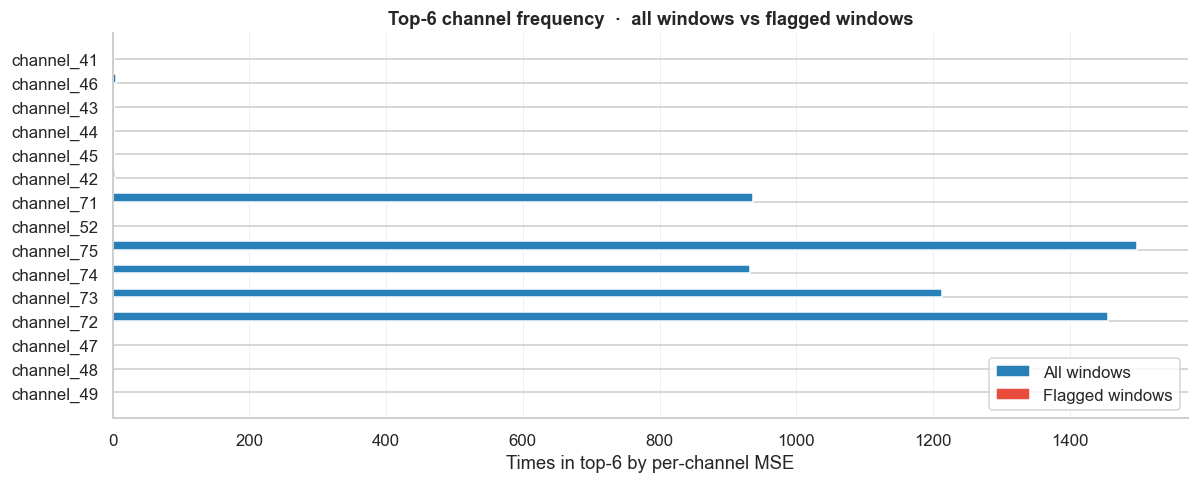


Total windows: 1,500   ·   flagged: 2 (0.13%)


In [30]:
# Frequency over windows where the model flagged anomaly only
from sentinel.ml_logic.scorer import broadcast_window_scores_to_rows

# Reconstruct window-level prediction from row labels: a window is flagged
# if its centre row is flagged. Cheap proxy: take window_scores > threshold.
win_scores = rep['window_scores']
win_pred   = (win_scores > PCA_THRESHOLD).astype(np.int8)

freq_all     = np.bincount(window_top_channels.ravel(), minlength=len(features))
freq_flagged = np.bincount(window_top_channels[win_pred == 1].ravel(), minlength=len(features)) \
               if win_pred.any() else np.zeros(len(features), dtype=int)

df_top = pd.DataFrame({
    'channel'   : features,
    'all_wins'  : freq_all,
    'flagged'   : freq_flagged,
}).sort_values('flagged', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(df_top))
ax.barh(y - 0.18, df_top['all_wins'],  0.36, color=NOMINAL_COLOR, label='All windows', edgecolor='white')
ax.barh(y + 0.18, df_top['flagged'],   0.36, color=ANOMALY_COLOR, label='Flagged windows', edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels(df_top['channel'])
ax.invert_yaxis()
ax.set_xlabel('Times in top-6 by per-channel MSE')
ax.set_title('Top-6 channel frequency  ·  all windows vs flagged windows', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='x', color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

print(f'\nTotal windows: {len(win_scores):,}   ·   flagged: {int(win_pred.sum()):,} ({win_pred.mean():.2%})')
